# FMA-Medium Genre Cleaning
**Goal:** Filter FMA-medium metadata to the 10 selected genres, verify one-to-one mapping, remove ambiguous/missing labels, build a clean CSV for training.

Output → `data/FMA/fma_medium_genre_clean.csv`

In [1]:
import os
import pandas as pd

# ── Paths ────────────────────────────────────────────────────────
PROJECT_ROOT = os.path.dirname(os.path.abspath("__file__"))  # training/
PROJECT_ROOT = os.path.dirname(PROJECT_ROOT)                  # Muud/
DATA_DIR     = os.path.join(PROJECT_ROOT, "data", "FMA")
METADATA_DIR = os.path.join(DATA_DIR, "fma_metadata")
AUDIO_DIR    = os.path.join(DATA_DIR, "fma_medium", "fma_medium")

print(f"Metadata : {METADATA_DIR}")
print(f"Audio    : {AUDIO_DIR}")

Metadata : c:\Users\adith\Documents\Study\Coding\Muud\data\FMA\fma_metadata
Audio    : c:\Users\adith\Documents\Study\Coding\Muud\data\FMA\fma_medium\fma_medium


In [2]:
# ── Load tracks.csv (multi-level header) ─────────────────────────
def find_csv(root_dir: str, filename: str) -> str:
    for dirpath, _, filenames in os.walk(root_dir):
        if filename in filenames:
            return os.path.join(dirpath, filename)
    raise FileNotFoundError(f"{filename} not found under {root_dir}")

tracks_path = find_csv(METADATA_DIR, "tracks.csv")
tracks = pd.read_csv(tracks_path, index_col=0, header=[0, 1])

# Flatten multi-level columns → "group.column"
tracks.columns = [f"{a}.{b}" for a, b in tracks.columns]
print(f"tracks.csv loaded : {tracks.shape[0]} rows × {tracks.shape[1]} cols")

tracks.csv loaded : 106574 rows × 52 cols


In [3]:
# ── Filter to medium subset ──────────────────────────────────────
SUBSETS = {"small", "medium"}
medium = tracks.loc[tracks["set.subset"].isin(SUBSETS)].copy()
print(f"Tracks in medium subset: {len(medium)}")

GENRE_COL = "track.genre_top"
print(f"Non-null genre labels  : {medium[GENRE_COL].notna().sum()}")
print(f"Null genre labels      : {medium[GENRE_COL].isna().sum()}")

Tracks in medium subset: 25000
Non-null genre labels  : 25000
Null genre labels      : 0


In [4]:
# ── Define the 10 selected genres ────────────────────────────────
SELECTED_GENRES = [
    "Classical",
    "Electronic",
    "Experimental",
    "Folk",
    "Hip-Hop",
    "Instrumental",
    "International",
    "Old-Time / Historic",
    "Pop",
    "Rock",
]

# Alphabetical → deterministic genre_index 0–9
GENRE_TO_IDX = {g: i for i, g in enumerate(SELECTED_GENRES)}
print("Genre → Index mapping:")
for g, i in GENRE_TO_IDX.items():
    print(f"  {i} : {g}")

Genre → Index mapping:
  0 : Classical
  1 : Electronic
  2 : Experimental
  3 : Folk
  4 : Hip-Hop
  5 : Instrumental
  6 : International
  7 : Old-Time / Historic
  8 : Pop
  9 : Rock


In [5]:
# ── Step 1: Keep only tracks whose genre_top is in SELECTED_GENRES ─
filtered = medium.loc[medium[GENRE_COL].isin(SELECTED_GENRES)].copy()
print(f"Tracks after genre filter: {len(filtered)}  (dropped {len(medium) - len(filtered)})")

# ── Step 2: Verify each track has exactly one top-level genre ─────
# genre_top is already a single value per row — assert no pipes / commas
assert filtered[GENRE_COL].str.contains(r"[|,;]", na=False).sum() == 0, \
    "Found multi-genre entries in genre_top column!"
print("✓ Every track has exactly one top-level genre label.")

Tracks after genre filter: 24071  (dropped 929)
✓ Every track has exactly one top-level genre label.


In [6]:
# ── Step 3: Build file_path and verify audio files exist ──────────
def tid_to_path(tid: int) -> str:
    """Convert track_id → relative path like '000/000002.mp3'."""
    fname = f"{tid:06d}.mp3"
    return os.path.join(fname[:3], fname)

filtered["file_path"] = filtered.index.map(tid_to_path)

# Check which files actually exist on disk
filtered["file_exists"] = filtered["file_path"].apply(
    lambda p: os.path.isfile(os.path.join(AUDIO_DIR, p))
)
missing = (~filtered["file_exists"]).sum()
print(f"Audio files found   : {filtered['file_exists'].sum()}")
print(f"Audio files missing : {missing}")

# Remove tracks with missing audio
if missing > 0:
    filtered = filtered.loc[filtered["file_exists"]].copy()
    print(f"After removing missing: {len(filtered)} tracks")
else:
    print("✓ All audio files present.")

Audio files found   : 24071
Audio files missing : 0
✓ All audio files present.


In [7]:
# ── Step 4: Build clean DataFrame ─────────────────────────────────
clean = pd.DataFrame({
    "track_id":    filtered.index,
    "file_path":   filtered["file_path"].values,
    "genre_label": filtered[GENRE_COL].values,
})
clean["genre_index"] = clean["genre_label"].map(GENRE_TO_IDX)

# Sanity checks
assert clean["genre_index"].isna().sum() == 0, "Unmapped genres found!"
clean["genre_index"] = clean["genre_index"].astype(int)

clean = clean.reset_index(drop=True)
print(f"Clean DataFrame: {len(clean)} rows × {clean.shape[1]} cols")
clean.head(10)

Clean DataFrame: 24071 rows × 4 cols


,track_id,file_path,genre_label,genre_index
0,2,000\000002.mp3,Hip-Hop,4
1,3,000\000003.mp3,Hip-Hop,4
2,5,000\000005.mp3,Hip-Hop,4
3,10,000\000010.mp3,Pop,8
4,134,000\000134.mp3,Hip-Hop,4
5,136,000\000136.mp3,Rock,9
6,139,000\000139.mp3,Folk,3
7,140,000\000140.mp3,Folk,3
8,141,000\000141.mp3,Folk,3
9,148,000\000148.mp3,Experimental,2


In [8]:
# ── Step 5: Save to CSV ───────────────────────────────────────────
out_path = os.path.join(DATA_DIR, "fma_medium_genre_clean.csv")
clean.to_csv(out_path, index=False)
print(f"Saved → {out_path}")

Saved → c:\Users\adith\Documents\Study\Coding\Muud\data\FMA\fma_medium_genre_clean.csv


In [9]:
# ── Step 6: Print summary ─────────────────────────────────────────
print(f"Final number of tracks: {len(clean)}\n")

dist = (
    clean.groupby(["genre_index", "genre_label"])
    .size()
    .reset_index(name="count")
    .sort_values("genre_index")
)

print("Class distribution:")
print("─" * 42)
for _, row in dist.iterrows():
    bar = "█" * (row["count"] // 50)
    print(f"  {row['genre_index']}  {row['genre_label']:<22s} {row['count']:>5d}  {bar}")
print("─" * 42)
print(f"  {'TOTAL':<25s} {dist['count'].sum():>5d}")

Final number of tracks: 24071

Class distribution:
──────────────────────────────────────────
  0  Classical                619  ████████████
  1  Electronic              6314  ██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
  2  Experimental            2251  █████████████████████████████████████████████
  3  Folk                    1519  ██████████████████████████████
  4  Hip-Hop                 2201  ████████████████████████████████████████████
  5  Instrumental            1350  ███████████████████████████
  6  International           1018  ████████████████████
  7  Old-Time / Historic      510  ██████████
  8  Pop                     1186  ███████████████████████
  9  Rock                    7103  ██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
──────────────────────────────────────────
  TOTAL                 

In [10]:
# ── Step 7: Stratified train / validation split (80/20) ──────────
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    clean,
    test_size=0.20,
    random_state=42,
    stratify=clean["genre_index"],
)

train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)

print(f"Train size      : {len(train_df)}")
print(f"Validation size : {len(val_df)}")
print(f"Split ratio     : {len(train_df)/len(clean):.2%} / {len(val_df)/len(clean):.2%}")

# Save splits
train_path = os.path.join(DATA_DIR, "fma_medium_train.csv")
val_path   = os.path.join(DATA_DIR, "fma_medium_val.csv")
train_df.to_csv(train_path, index=False)
val_df.to_csv(val_path, index=False)
print(f"\nSaved → {train_path}")
print(f"Saved → {val_path}")

Train size      : 19256
Validation size : 4815
Split ratio     : 80.00% / 20.00%

Saved → c:\Users\adith\Documents\Study\Coding\Muud\data\FMA\fma_medium_train.csv
Saved → c:\Users\adith\Documents\Study\Coding\Muud\data\FMA\fma_medium_val.csv


In [11]:
# ── Step 8: Compute class weights ─────────────────────────────────
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

classes = np.arange(len(SELECTED_GENRES))          # 0–9
weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_df["genre_index"].values,
)

CLASS_WEIGHTS = {int(c): round(float(w), 4) for c, w in zip(classes, weights)}

print("Class weights (balanced):")
print("─" * 48)
for idx in sorted(CLASS_WEIGHTS):
    genre = SELECTED_GENRES[idx]
    w = CLASS_WEIGHTS[idx]
    print(f"  {idx}  {genre:<22s}  weight = {w:.4f}")
print("─" * 48)
print(f"\nCLASS_WEIGHTS = {CLASS_WEIGHTS}")

Class weights (balanced):
────────────────────────────────────────────────
  0  Classical               weight = 3.8901
  1  Electronic              weight = 0.3812
  2  Experimental            weight = 1.0692
  3  Folk                    weight = 1.5849
  4  Hip-Hop                 weight = 1.0935
  5  Instrumental            weight = 1.7830
  6  International           weight = 2.3656
  7  Old-Time / Historic     weight = 4.7196
  8  Pop                     weight = 2.0291
  9  Rock                    weight = 0.3389
────────────────────────────────────────────────

CLASS_WEIGHTS = {0: 3.8901, 1: 0.3812, 2: 1.0692, 3: 1.5849, 4: 1.0935, 5: 1.783, 6: 2.3656, 7: 4.7196, 8: 2.0291, 9: 0.3389}


In [12]:
# ── Step 9: Mel spectrogram extraction function ──────────────────
import librosa
import numpy as np
from tqdm import tqdm

# ── Constants ────────────────────────────────────────────────────
SR           = 22050
DURATION     = 30          # seconds
N_SEGMENTS   = 3
N_MELS       = 128
N_FFT        = 2048
HOP_LENGTH   = 512
TOTAL_SAMPLES = SR * DURATION                       # 661 500
SEG_SAMPLES   = TOTAL_SAMPLES // N_SEGMENTS         # 220 500

def extract_mel_segments(file_path: str) -> list[np.ndarray]:
    """Load audio, split into N_SEGMENTS, return list of normalised log-mel arrays.

    Each array has shape (N_MELS, T) where T = ceil(SEG_SAMPLES / HOP_LENGTH) + 1.
    """
    # Load mono at target SR
    y, _ = librosa.load(file_path, sr=SR, mono=True)

    # Pad or trim to exactly TOTAL_SAMPLES
    if len(y) < TOTAL_SAMPLES:
        y = np.pad(y, (0, TOTAL_SAMPLES - len(y)))
    else:
        y = y[:TOTAL_SAMPLES]

    segments = []
    for i in range(N_SEGMENTS):
        start = i * SEG_SAMPLES
        end   = start + SEG_SAMPLES
        seg   = y[start:end]

        # Mel spectrogram → log scale
        mel = librosa.feature.melspectrogram(
            y=seg, sr=SR, n_mels=N_MELS, n_fft=N_FFT, hop_length=HOP_LENGTH
        )
        mel_db = librosa.power_to_db(mel, ref=np.max)

        # Normalise (zero mean, unit std)
        mean = mel_db.mean()
        std  = mel_db.std()
        if std > 0:
            mel_db = (mel_db - mean) / std
        else:
            mel_db = mel_db - mean

        segments.append(mel_db)

    return segments

# Quick sanity check with first train track
_test_path = os.path.join(AUDIO_DIR, train_df.iloc[0]["file_path"])
_segs = extract_mel_segments(_test_path)
print(f"Segments per track : {len(_segs)}")
print(f"Segment shape      : {_segs[0].shape}")
print(f"Expected time bins : ~{SEG_SAMPLES // HOP_LENGTH + 1}")

c:\Users\adith\anaconda3\envs\emotioncnn\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Segments per track : 3
Segment shape      : (128, 431)
Expected time bins : ~431


In [13]:
# ── Step 10: Extract training set ─────────────────────────────────
def extract_dataset(df: pd.DataFrame, label: str):
    """Extract mel segments for every row in *df*. Returns X, y arrays."""
    X, y = [], []
    errors = []
    for idx, row in tqdm(df.iterrows(), total=len(df), desc=label):
        fpath = os.path.join(AUDIO_DIR, row["file_path"])
        try:
            segs = extract_mel_segments(fpath)
            for s in segs:
                X.append(s)
                y.append(row["genre_index"])
        except Exception as e:
            errors.append((row["track_id"], str(e)))
    if errors:
        print(f"\n⚠ {len(errors)} files failed:")
        for tid, msg in errors[:10]:
            print(f"    track {tid}: {msg}")
        if len(errors) > 10:
            print(f"    … and {len(errors) - 10} more")
    else:
        print(f"\n✓ All {len(df)} files processed without errors.")
    return X, y

X_train_list, y_train_list = extract_dataset(train_df, "Train")
print(f"\nRaw segments collected: {len(X_train_list)}")

Train:   5%|▍         | 871/19256 [01:26<31:00,  9.88it/s]C:\Users\adith\AppData\Local\Temp\ipykernel_10168\1072600541.py:22: UserWarning: PySoundFile failed. Trying audioread instead.
  y, _ = librosa.load(file_path, sr=SR, mono=True)
c:\Users\adith\anaconda3\envs\emotioncnn\lib\site-packages\librosa\core\audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
Train: 100%|██████████| 19256/19256 [33:40<00:00,  9.53it/s]


⚠ 19 files failed:
    track 108925: 
    track 127336: 
    track 98559: 
    track 98567: 
    track 98565: 
    track 65753: 
    track 98566: 
    track 80391: 
    track 126981: 
    track 105247: 
    … and 9 more

Raw segments collected: 57711


In [14]:
# ── Step 11: Extract validation set ───────────────────────────────
X_val_list, y_val_list = extract_dataset(val_df, "Val")
print(f"\nRaw segments collected: {len(X_val_list)}")

Val:  98%|█████████▊| 4698/4815 [09:02<00:13,  8.36it/s]C:\Users\adith\AppData\Local\Temp\ipykernel_10168\1072600541.py:22: UserWarning: PySoundFile failed. Trying audioread instead.
  y, _ = librosa.load(file_path, sr=SR, mono=True)
Val: 100%|██████████| 4815/4815 [09:16<00:00,  8.66it/s]


⚠ 1 files failed:
    track 98568: 

Raw segments collected: 14442


In [15]:
# ── Step 12: Convert to numpy arrays & add channel dim ───────────
X_train = np.array(X_train_list)[..., np.newaxis]   # (N, 128, T, 1)
y_train = np.array(y_train_list)

X_val = np.array(X_val_list)[..., np.newaxis]
y_val = np.array(y_val_list)

print(f"X_train : {X_train.shape}  dtype={X_train.dtype}")
print(f"y_train : {y_train.shape}  dtype={y_train.dtype}")
print(f"X_val   : {X_val.shape}  dtype={X_val.dtype}")
print(f"y_val   : {y_val.shape}  dtype={y_val.dtype}")
print(f"\nTotal samples : {len(X_train) + len(X_val)}")

X_train : (57711, 128, 431, 1)  dtype=float32
y_train : (57711,)  dtype=int32
X_val   : (14442, 128, 431, 1)  dtype=float32
y_val   : (14442,)  dtype=int32

Total samples : 72153


In [16]:
# ── Step 13: Save arrays to disk ──────────────────────────────────
FEAT_DIR = os.path.join(DATA_DIR, "features")
os.makedirs(FEAT_DIR, exist_ok=True)

np.save(os.path.join(FEAT_DIR, "X_train.npy"), X_train)
np.save(os.path.join(FEAT_DIR, "y_train.npy"), y_train)
np.save(os.path.join(FEAT_DIR, "X_val.npy"),   X_val)
np.save(os.path.join(FEAT_DIR, "y_val.npy"),    y_val)

total_mb = sum(a.nbytes for a in [X_train, y_train, X_val, y_val]) / 1e6
print(f"Saved to {FEAT_DIR}/")
print(f"  X_train.npy  {X_train.nbytes / 1e6:.1f} MB")
print(f"  y_train.npy  {y_train.nbytes / 1e6:.3f} MB")
print(f"  X_val.npy    {X_val.nbytes / 1e6:.1f} MB")
print(f"  y_val.npy    {y_val.nbytes / 1e6:.3f} MB")
print(f"  Total        {total_mb:.1f} MB")

Saved to c:\Users\adith\Documents\Study\Coding\Muud\data\FMA\features/
  X_train.npy  12735.2 MB
  y_train.npy  0.231 MB
  X_val.npy    3186.9 MB
  y_val.npy    0.058 MB
  Total        15922.4 MB


In [1]:
# ── Step 14: Load saved features from disk ────────────────────────
import os, numpy as np

# Force CPU-only (set BEFORE any TensorFlow import)
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

PROJECT_ROOT = os.path.dirname(os.path.abspath("__file__"))
PROJECT_ROOT = os.path.dirname(PROJECT_ROOT)
FEAT_DIR     = os.path.join(PROJECT_ROOT, "data", "FMA", "features")

X_train = np.load(os.path.join(FEAT_DIR, "X_train.npy"), mmap_mode="r")
y_train = np.load(os.path.join(FEAT_DIR, "y_train.npy"))
X_val   = np.load(os.path.join(FEAT_DIR, "X_val.npy"), mmap_mode="r")
y_val   = np.load(os.path.join(FEAT_DIR, "y_val.npy"))

print(f"X_train : {X_train.shape}  y_train : {y_train.shape}")
print(f"X_val   : {X_val.shape}  y_val   : {y_val.shape}")

# Restore CLASS_WEIGHTS from previous step
CLASS_WEIGHTS = {0: 3.8901, 1: 0.3812, 2: 1.0692, 3: 1.5849,
                 4: 1.0935, 5: 1.783,  6: 2.3656, 7: 4.7196,
                 8: 2.0291, 9: 0.3389}

SELECTED_GENRES = [
    "Classical", "Electronic", "Experimental", "Folk", "Hip-Hop",
    "Instrumental", "International", "Old-Time / Historic", "Pop", "Rock",
]
print(f"\nClasses : {len(SELECTED_GENRES)}")
print(f"Weights : {CLASS_WEIGHTS}")
print("GPU disabled — training will use CPU only.")

X_train : (57711, 128, 431, 1)  y_train : (57711,)
X_val   : (14442, 128, 431, 1)  y_val   : (14442,)

Classes : 10
Weights : {0: 3.8901, 1: 0.3812, 2: 1.0692, 3: 1.5849, 4: 1.0935, 5: 1.783, 6: 2.3656, 7: 4.7196, 8: 2.0291, 9: 0.3389}
GPU disabled — training will use CPU only.


In [2]:
# ── Step 15: Build CNN model ──────────────────────────────────────
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import tensorflow as tf
from tensorflow import keras
from keras import layers, models

INPUT_SHAPE = (128, 431, 1)
NUM_CLASSES = 10

model = models.Sequential([
    # ── Block 1 ──────────────────────────────────────────────────
    layers.Conv2D(32, (3, 3), padding="same", input_shape=INPUT_SHAPE),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    # ── Block 2 ──────────────────────────────────────────────────
    layers.Conv2D(64, (3, 3), padding="same"),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.MaxPooling2D(),
    layers.Dropout(0.3),

    # ── Block 3 ──────────────────────────────────────────────────
    layers.Conv2D(128, (3, 3), padding="same"),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.MaxPooling2D(),
    layers.Dropout(0.3),

    # ── Block 4 ──────────────────────────────────────────────────
    layers.Conv2D(256, (3, 3), padding="same"),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.MaxPooling2D(),
    layers.Dropout(0.4),

    # ── Head ─────────────────────────────────────────────────────
    layers.GlobalAveragePooling2D(),
    layers.Dense(256),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.Dropout(0.5),
    layers.Dense(NUM_CLASSES, activation="softmax"),
])

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 128, 431, 32)      320       
                                                                 
 batch_normalization (BatchN  (None, 128, 431, 32)     128       
 ormalization)                                                   
                                                                 
 re_lu (ReLU)                (None, 128, 431, 32)      0         
                                                                 
 max_pooling2d (MaxPooling2D  (None, 64, 215, 32)      0         
 )                                                               
                                                                 
 dropout (Dropout)           (None, 64, 215, 32)       0         
                                                                 
 conv2d_1 (Conv2D)           (None, 64, 215, 64)       1

In [3]:
# ── Step 16: Compile & Train ──────────────────────────────────────
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=6,
        restore_best_weights=True,
        verbose=1,
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        patience=3,
        factor=0.5,
        min_lr=1e-6,
        verbose=1,
    ),
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    batch_size=32,
    epochs=50,
    class_weight=CLASS_WEIGHTS,
    callbacks=callbacks,
    verbose=1,
)

Epoch 1/50
1804/1804 [==============================] - 2297s 1s/step - loss: 1.5849 - accuracy: 0.4474 - val_loss: 3.3634 - val_accuracy: 0.2103 - lr: 5.0000e-04
Epoch 2/50
1804/1804 [==============================] - 2264s 1s/step - loss: 1.3284 - accuracy: 0.5304 - val_loss: 2.9752 - val_accuracy: 0.2142 - lr: 5.0000e-04
Epoch 3/50
1804/1804 [==============================] - 2278s 1s/step - loss: 1.2470 - accuracy: 0.5601 - val_loss: 1.9458 - val_accuracy: 0.3876 - lr: 5.0000e-04
Epoch 4/50
1804/1804 [==============================] - 2314s 1s/step - loss: 1.1981 - accuracy: 0.5740 - val_loss: 2.3261 - val_accuracy: 0.2194 - lr: 5.0000e-04
Epoch 5/50
1804/1804 [==============================] - 2314s 1s/step - loss: 1.1519 - accuracy: 0.5868 - val_loss: 1.6380 - val_accuracy: 0.4331 - lr: 5.0000e-04
Epoch 6/50
1804/1804 [==============================] - 2295s 1s/step - loss: 1.1203 - accuracy: 0.5968 - val_loss: 1.5403 - val_accuracy: 0.4638 - lr: 5.0000e-04
Epoch 7/50
1804/1804 [

In [3]:
# ── Step 17: SpecAugment function ─────────────────────────────────
import tensorflow as tf

def spec_augment(mel, label):
    """Apply SpecAugment (freq + time masking) with 50% probability.

    Args:
        mel:   (128, 431, 1) float32 tensor
        label: scalar int
    Returns:
        (mel, label) — possibly augmented
    """
    def _augment(m):
        shape = tf.shape(m)                       # (128, 431, 1)
        n_mels = shape[0]
        n_time = shape[1]

        # ── Frequency masking: mask 10–20 contiguous mel bins ────
        f_width = tf.random.uniform([], 10, 21, dtype=tf.int32)
        f_start = tf.random.uniform([], 0, n_mels - f_width, dtype=tf.int32)
        freq_mask = tf.concat([
            tf.ones([f_start, n_time, 1]),
            tf.zeros([f_width, n_time, 1]),
            tf.ones([n_mels - f_start - f_width, n_time, 1]),
        ], axis=0)
        m = m * freq_mask

        # ── Time masking: mask 20–40 contiguous time frames ─────
        t_width = tf.random.uniform([], 20, 41, dtype=tf.int32)
        t_start = tf.random.uniform([], 0, n_time - t_width, dtype=tf.int32)
        time_mask = tf.concat([
            tf.ones([n_mels, t_start, 1]),
            tf.zeros([n_mels, t_width, 1]),
            tf.ones([n_mels, n_time - t_start - t_width, 1]),
        ], axis=1)
        m = m * time_mask
        return m

    # Apply augmentation with 50% probability
    do_aug = tf.random.uniform([]) < 0.5
    mel = tf.cond(do_aug, lambda: _augment(mel), lambda: mel)
    return mel, label

# Quick visual test
_sample = tf.constant(X_train[0])
_aug, _ = spec_augment(_sample, 0)
print(f"Input shape  : {_sample.shape}")
print(f"Output shape : {_aug.shape}")
print("✓ spec_augment works.")

Input shape  : (128, 431, 1)
Output shape : (128, 431, 1)
✓ spec_augment works.


In [7]:
# ── Step 18: Build tf.data pipelines (generator-based, low RAM) ──
BATCH_SIZE = 32
AUTOTUNE   = tf.data.AUTOTUNE
OUT_SIG    = (tf.TensorSpec(shape=(128, 431, 1), dtype=tf.float32),
              tf.TensorSpec(shape=(),            dtype=tf.int32))

N_TRAIN = len(y_train)
N_VAL   = len(y_val)

def _train_gen():
    """Yield (spectrogram, label) from mmap arrays in shuffled order."""
    idxs = np.random.permutation(N_TRAIN)
    for i in idxs:
        yield X_train[i].astype(np.float32), y_train[i].astype(np.int32)

def _val_gen():
    for i in range(N_VAL):
        yield X_val[i].astype(np.float32), y_val[i].astype(np.int32)

train_dataset = (
    tf.data.Dataset.from_generator(_train_gen, output_signature=OUT_SIG)
    .map(spec_augment, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
    .repeat()            # ← re-invoke generator each epoch
)

val_dataset = (
    tf.data.Dataset.from_generator(_val_gen, output_signature=OUT_SIG)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
    .repeat()            # ← re-invoke generator each epoch
)

print(f"Train steps/epoch : {N_TRAIN // BATCH_SIZE + 1}")
print(f"Val steps/epoch   : {N_VAL // BATCH_SIZE + 1}")
print("✓ Datasets repeat indefinitely — steps_per_epoch controls epoch boundary.")

Train steps/epoch : 1804
Val steps/epoch   : 452
✓ Datasets repeat indefinitely — steps_per_epoch controls epoch boundary.


In [8]:
# ── Step 19: Rebuild fresh model (same architecture) & train ─────
import math
from keras import layers, models
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

model_aug = models.Sequential([
    # ── Block 1 ──────────────────────────────────────────────────
    layers.Conv2D(32, (3, 3), padding="same", input_shape=INPUT_SHAPE),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),
    # ── Block 2 ──────────────────────────────────────────────────
    layers.Conv2D(64, (3, 3), padding="same"),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.MaxPooling2D(),
    layers.Dropout(0.3),
    # ── Block 3 ──────────────────────────────────────────────────
    layers.Conv2D(128, (3, 3), padding="same"),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.MaxPooling2D(),
    layers.Dropout(0.3),
    # ── Block 4 ──────────────────────────────────────────────────
    layers.Conv2D(256, (3, 3), padding="same"),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.MaxPooling2D(),
    layers.Dropout(0.4),
    # ── Head ─────────────────────────────────────────────────────
    layers.GlobalAveragePooling2D(),
    layers.Dense(256),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.Dropout(0.5),
    layers.Dense(NUM_CLASSES, activation="softmax"),
])

model_aug.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

callbacks_aug = [
    EarlyStopping(
        monitor="val_loss",
        patience=6,
        restore_best_weights=True,
        verbose=1,
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        patience=3,
        factor=0.5,
        min_lr=1e-6,
        verbose=1,
    ),
]

STEPS_PER_EPOCH  = math.ceil(N_TRAIN / BATCH_SIZE)   # 1804
VALIDATION_STEPS = math.ceil(N_VAL / BATCH_SIZE)      # 452

print(f"Model rebuilt with fresh weights.")
print(f"Steps/epoch: {STEPS_PER_EPOCH}  |  Val steps: {VALIDATION_STEPS}")
print("Starting training with SpecAugment…\n")

history_aug = model_aug.fit(
    train_dataset,
    validation_data=val_dataset,
    steps_per_epoch=STEPS_PER_EPOCH,
    validation_steps=VALIDATION_STEPS,
    epochs=50,
    class_weight=CLASS_WEIGHTS,
    callbacks=callbacks_aug,
    verbose=1,
)

Model rebuilt with fresh weights.
Steps/epoch: 1804  |  Val steps: 452
Starting training with SpecAugment…

Epoch 1/50
1804/1804 [==============================] - 2152s 1s/step - loss: 1.6222 - accuracy: 0.4379 - val_loss: 2.3708 - val_accuracy: 0.3067 - lr: 5.0000e-04
Epoch 2/50
1804/1804 [==============================] - 2168s 1s/step - loss: 1.3588 - accuracy: 0.5261 - val_loss: 1.7115 - val_accuracy: 0.4787 - lr: 5.0000e-04
Epoch 3/50
1804/1804 [==============================] - 2170s 1s/step - loss: 1.2745 - accuracy: 0.5539 - val_loss: 1.9233 - val_accuracy: 0.3993 - lr: 5.0000e-04
Epoch 4/50
1804/1804 [==============================] - 2162s 1s/step - loss: 1.2223 - accuracy: 0.5713 - val_loss: 1.6306 - val_accuracy: 0.4706 - lr: 5.0000e-04
Epoch 5/50
1804/1804 [==============================] - 2152s 1s/step - loss: 1.1805 - accuracy: 0.5856 - val_loss: 1.4917 - val_accuracy: 0.5055 - lr: 5.0000e-04
Epoch 6/50
1804/1804 [==============================] - 2147s 1s/step - loss:

In [9]:
# ── Step 20: Save trained model ───────────────────────────────────
import os

MODEL_DIR = os.path.join(PROJECT_ROOT, "models")
os.makedirs(MODEL_DIR, exist_ok=True)

save_path = os.path.join(MODEL_DIR, "genre_fma_cnn.keras")
model_aug.save(save_path)
print(f"✓ Model saved → {save_path}")

# Also print final training summary
best_val_acc = max(history_aug.history["val_accuracy"])
best_epoch   = history_aug.history["val_accuracy"].index(best_val_acc) + 1
final_lr     = history_aug.history["lr"][-1]
total_epochs = len(history_aug.history["loss"])

print(f"\n── Training Summary ──────────────────────")
print(f"  Total epochs trained : {total_epochs}")
print(f"  Best val_accuracy    : {best_val_acc:.4f}  (epoch {best_epoch})")
print(f"  Final learning rate  : {final_lr:.2e}")
print(f"──────────────────────────────────────────")

✓ Model saved → c:\Users\adith\Documents\Study\Coding\Muud\models\genre_fma_cnn.keras

── Training Summary ──────────────────────
  Total epochs trained : 35
  Best val_accuracy    : 0.6804  (epoch 29)
  Final learning rate  : 6.25e-05
──────────────────────────────────────────


✓ Loaded model from c:\Users\adith\Documents\Study\Coding\Muud\models\genre_fma_cnn.keras
Running predictions on validation set…
452/452 [==============================] - 106s 233ms/step


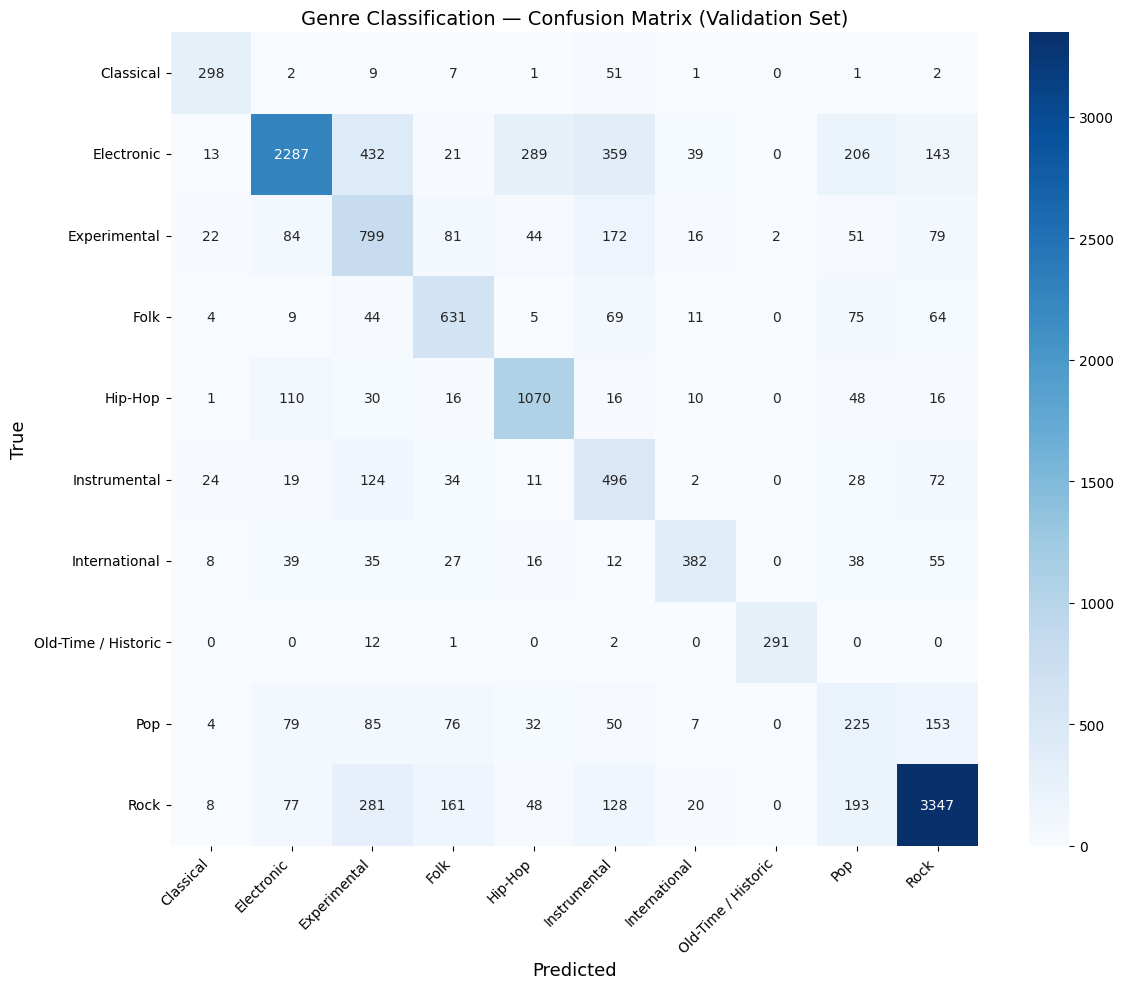


── Classification Report ──────────────────────────────────
                     precision    recall  f1-score   support

          Classical      0.780     0.801     0.790       372
         Electronic      0.845     0.604     0.704      3789
       Experimental      0.432     0.592     0.499      1350
               Folk      0.598     0.692     0.642       912
            Hip-Hop      0.706     0.812     0.755      1317
       Instrumental      0.366     0.612     0.458       810
      International      0.783     0.624     0.695       612
Old-Time / Historic      0.993     0.951     0.972       306
                Pop      0.260     0.316     0.286       711
               Rock      0.851     0.785     0.817      4263

           accuracy                          0.680     14442
          macro avg      0.661     0.679     0.662     14442
       weighted avg      0.723     0.680     0.692     14442



In [10]:
# ── Step 21: Confusion Matrix & Per-Class Report ─────────────────
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from keras.models import load_model

# Load model (in case kernel restarted)
model_path = os.path.join(PROJECT_ROOT, "models", "genre_fma_cnn.keras")
model_eval = load_model(model_path)
print(f"✓ Loaded model from {model_path}")

# Predict on validation set (use generator to avoid OOM)
print("Running predictions on validation set…")
y_pred_probs = model_eval.predict(
    val_dataset,
    steps=VALIDATION_STEPS,
    verbose=1,
)
y_pred = np.argmax(y_pred_probs[:len(y_val)], axis=1)
y_true = y_val[:len(y_pred)]

# Confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=np.arange(NUM_CLASSES))

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=SELECTED_GENRES,
    yticklabels=SELECTED_GENRES,
    ax=ax,
)
ax.set_xlabel("Predicted", fontsize=13)
ax.set_ylabel("True", fontsize=13)
ax.set_title("Genre Classification — Confusion Matrix (Validation Set)", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Classification report
print("\n── Classification Report ──────────────────────────────────")
print(classification_report(
    y_true, y_pred,
    target_names=SELECTED_GENRES,
    digits=3,
))